# Resume Dashboard — SVG Generator

Generates 7 SVG files from structured JSON data for the multilingual resume dashboard.

## Cell 1: Imports

In [2]:
import json
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

## Cell 2: Path Configuration & Color Constants

In [3]:
DATA_DIR = Path.cwd() / "data"
OUTPUT_DIR = Path.cwd() / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

COLORS = {
    "crimson": "#7D1A1A",
    "forest": "#2D5016",
    "gold": "#B8922A",
    "gray": "#9A9080",
    "white": "#FFFFFF",
    "black": "#1a1a1a"
}

def resolve_color(name):
    """Map color names to hex values."""
    return COLORS.get(name, name)

## Cell 3: Data Loading

In [4]:
def load_all_data():
    """Load all 7 JSON files from DATA_DIR."""
    files = {
        "timeline": "timeline.json",
        "captain_fbbm": "captain_fbbm.json",
        "radar": "radar.json",
        "pip": "pip.json",
        "donut": "donut.json",
        "kpi": "kpi.json",
        "education": "education.json"
    }
    data = {}
    for key, filename in files.items():
        filepath = DATA_DIR / filename
        with open(filepath, 'r', encoding='utf-8') as f:
            data[key] = json.load(f)
    return data

data = load_all_data()
print(f"Loaded {len(data)} data files from {DATA_DIR}")

Loaded 7 data files from c:\Users\Admin\Project_Central\05_JobHunt\Resume\Dashboard\data


## Cell 4: Validation

In [5]:
def validate_timeline(d):
    assert "roles" in d, "timeline.json missing 'roles'"
    for role in d["roles"]:
        for key in ["id", "start_date", "end_date", "duration_years", "color", "row"]:
            assert key in role, f"Role {role.get('id')} missing '{key}'"
    print("  ✓ timeline")

def validate_radar(d):
    assert "radars" in d, "radar.json missing 'radars'"
    for radar in d["radars"]:
        for key in ["id", "title_de", "color", "axes"]:
            assert key in radar, f"Radar {radar.get('id')} missing '{key}'"
        for axis in radar["axes"]:
            for key in ["label_short_de", "value"]:
                assert key in axis, f"Axis missing '{key}'"
    print("  ✓ radar")

def validate_pip(d):
    assert "groups" in d, "pip.json missing 'groups'"
    for group in d["groups"]:
        for key in ["id", "title_de", "shape", "color", "skills"]:
            assert key in group, f"Group {group.get('id')} missing '{key}'"
        for skill in group["skills"]:
            for key in ["name_de", "value"]:
                assert key in skill, f"Skill missing '{key}'"
    print("  ✓ pip")

def validate_donut(d):
    assert "segments" in d, "donut.json missing 'segments'"
    assert "center" in d, "donut.json missing 'center'"
    assert "total_years" in d, "donut.json missing 'total_years'"
    print("  ✓ donut")

def validate_kpi(d):
    assert "kpi" in d, "kpi.json missing 'kpi'"
    for kpi in d["kpi"]:
        for key in ["id", "number", "unit", "label_de"]:
            assert key in kpi, f"KPI {kpi.get('id')} missing '{key}'"
    print("  ✓ kpi")

print("Validating data files...")
validate_timeline(data["timeline"])
validate_radar(data["radar"])
validate_pip(data["pip"])
validate_donut(data["donut"])
validate_kpi(data["kpi"])
print("All validations passed.")

Validating data files...
  ✓ timeline
  ✓ radar
  ✓ pip
  ✓ donut
  ✓ kpi
All validations passed.


## Cell 5: Transformations

In [6]:
def timeline_to_gantt(timeline_data):
    """Extract roles into structured format for Gantt chart."""
    roles = timeline_data["roles"]
    gantt_data = []
    for role in roles:
        start_dec = role.get("start_decimal", 2013)
        duration = role["duration_years"]
        gantt_data.append({
            "id": role["id"],
            "x_start": start_dec,
            "x_end": start_dec + duration,
            "width": duration,
            "row": role["row"],
            "label": role.get("label_short", role["id"]),
            "color_hex": resolve_color(role["color"]),
            "stemH": role.get("stemH", 0),
            "concurrent": role.get("concurrent", False),
            "location": role.get("location", "")
        })
    return gantt_data

def radar_to_polar(radar_entry):
    """Transform radar data for polar plotting."""
    axes = radar_entry["axes"]
    n = len(axes)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    values = [axis["value"] for axis in axes]
    labels = [axis["label_short_en"] for axis in axes]
    return {
        "angles": angles + [angles[0]],
        "values": values + [values[0]],
        "labels": labels,
        "color": resolve_color(radar_entry["color"]),
        "title": radar_entry.get("title_en", "")
    }

def pip_to_grid(pip_data):
    """Transform PIP data for grid layout."""
    groups = pip_data["groups"]
    grid_data = []
    position_index = 0
    for group in groups:
        for skill in group["skills"]:
            grid_data.append({
                "group_id": group["id"],
                "group_title": group.get("title_en", ""),
                "name": skill["name_en"],
                "normalized_value": skill["value"] / 10.0,
                "value": skill["value"],
                "shape": group.get("shape", "circle"),
                "color": resolve_color(group["color"]),
                "position_index": position_index
            })
            position_index += 1
    return grid_data

def donut_to_pie(donut_data):
    """Transform donut data for pie chart."""
    segments = donut_data["segments"]
    return {
        "sizes": [seg["pct"] for seg in segments],
        "colors": [resolve_color(seg["color"]) for seg in segments],
        "labels": [seg.get("label_en", seg.get("id", "")) for seg in segments],
        "center_number": donut_data["center"]["number"],
        "center_label": donut_data["center"]["label_en"]
    }

def kpi_to_strip(kpi_data):
    """Transform KPI data for strip display."""
    return [{
        "number": kpi["number"],
        "unit": kpi["unit"],
        "label": kpi.get("label_en", ""),
        "sub": kpi.get("sub_en", "")
    } for kpi in kpi_data["kpi"]]

print("Transformation functions defined.")

Transformation functions defined.


## Cell 6: SVG Generation Functions

In [7]:
def generate_timeline_svg(data, output_dir):
    """Generate Gantt-style timeline SVG."""
    roles = data["timeline"]["roles"]
    concurrent_ids = data["timeline"].get("concurrent_roles", [])
    
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.set_xlim(2013, 2025)
    ax.set_xticks(range(2013, 2026))
    ax.set_yticks(range(len(roles)))
    ax.set_yticklabels([r["label_short"] for r in roles])
    
    for i, role in enumerate(roles):
        color = COLORS.get(role["color"], role["color"])
        is_concurrent = role["id"] in concurrent_ids
        
        ax.barh(i, role["duration_years"], left=role["start_decimal"],
                height=0.6, color=color, alpha=0.7 if is_concurrent else 1.0)
        
        if is_concurrent:
            ax.barh(i, role["duration_years"], left=role["start_decimal"],
                    height=0.6, fill=False, edgecolor='black',
                    linestyle='--', linewidth=1)
        
        ax.text(role["start_decimal"] + role["duration_years"] / 2, i,
                role.get("location", ""), ha='center', va='center',
                fontsize=8, color='white' if not is_concurrent else 'black',
                fontweight='bold' if is_concurrent else 'normal')
    
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['bottom'].set_visible(True)
    
    plt.tight_layout()
    plt.savefig(output_dir / "timeline.svg", format='svg', bbox_inches='tight')
    plt.close()


def generate_radar_svg(radar_entry, filename, output_dir):
    """Generate radar chart SVG from single radar entry."""
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='polar'))
    
    axes_data = radar_entry["axes"]
    values = [a["value"] for a in axes_data]
    labels = [a["label_short_en"] for a in axes_data]
    angles = np.linspace(0, 2 * np.pi, len(axes_data), endpoint=False).tolist()
    
    values_closed = values + [values[0]]
    angles_closed = angles + [angles[0]]
    
    color = COLORS.get(radar_entry["color"], radar_entry["color"])
    ax.plot(angles_closed, values_closed, color=color, linewidth=2)
    ax.fill(angles_closed, values_closed, color=color, alpha=0.15)
    
    ax.set_xticks(angles)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels([])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title(radar_entry["title_en"], fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig(output_dir / filename, format='svg', bbox_inches='tight')
    plt.close()


def generate_all_radars(data, output_dir):
    """Generate all radar SVGs."""
    for radar in data["radar"]["radars"]:
        generate_radar_svg(radar, f"radar_{radar['id']}.svg", output_dir)


def generate_donut_svg(data, output_dir):
    """Generate donut chart SVG."""
    donut = data["donut"]
    segments = donut["segments"]
    
    fig, ax = plt.subplots(figsize=(6, 6))
    sizes = [seg["pct"] for seg in segments]
    colors = [COLORS.get(seg["color"], seg["color"]) for seg in segments]
    labels = [seg.get("label_en", seg.get("id", "")) for seg in segments]
    
    wedges, texts, autotexts = ax.pie(
        sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(width=0.4)
    )
    
    center_text = f"{donut['center']['number']}\n{donut['center']['label_en']}"
    ax.text(0, 0, center_text, ha='center', va='center',
            fontsize=20, fontweight='bold')
    
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.savefig(output_dir / "donut.svg", format='svg', bbox_inches='tight')
    plt.close()


def generate_pip_svg(data, output_dir):
    """Generate pip grid SVG (4×3 circles/squares)."""
    groups = data["pip"]["groups"]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    for row_idx, group in enumerate(groups):
        ax.text(1.5, 4 - row_idx + 0.3, group["title_en"],
                ha='center', va='bottom', fontsize=12, fontweight='bold',
                color=COLORS.get(group["color"], group["color"]))
        
        for col_idx, skill in enumerate(group["skills"]):
            x = col_idx + 0.5
            y = 3 - row_idx
            fill_ratio = skill["value"] / 10.0
            color = COLORS.get(group["color"], group["color"])
            
            if group["shape"] == "round":
                if fill_ratio > 0:
                    ax.add_patch(plt.Circle((x, y), 0.3, color=color, alpha=fill_ratio))
                ax.add_patch(plt.Circle((x, y), 0.3, fill=False, edgecolor=color, linewidth=1))
            else:
                if fill_ratio > 0:
                    ax.add_patch(mpatches.Rectangle((x - 0.3, y - 0.3), 0.6, 0.6,
                                                    color=color, alpha=fill_ratio))
                ax.add_patch(mpatches.Rectangle((x - 0.3, y - 0.3), 0.6, 0.6,
                                                fill=False, edgecolor=color, linewidth=1))
            
            ax.text(x, y - 0.5, skill["name_en"], ha='center', va='top', fontsize=8)
            ax.text(x, y, str(skill["value"]), ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if fill_ratio > 0.5 else 'black')
    
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 4)
    ax.set_aspect('equal')
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(output_dir / "pip.svg", format='svg', bbox_inches='tight')
    plt.close()


def generate_kpi_svg(data, output_dir):
    """Generate KPI strip SVG."""
    kpis = data["kpi"]["kpi"]
    
    fig, ax = plt.subplots(figsize=(12, 2))
    
    for i, kpi in enumerate(kpis):
        x = i * 3 + 1.5
        ax.text(x, 1.5, f"{kpi['number']}{kpi['unit']}",
                ha='center', va='center', fontsize=24, fontweight='bold')
        ax.text(x, 0.8, kpi["label_en"],
                ha='center', va='center', fontsize=12)
        if "sub_en" in kpi:
            ax.text(x, 0.3, kpi["sub_en"],
                    ha='center', va='center', fontsize=8, color='gray')
    
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 2)
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(output_dir / "kpi.svg", format='svg', bbox_inches='tight')
    plt.close()


print("All SVG generation functions defined.")

All SVG generation functions defined.


## Cell 7: Execute — Generate All SVGs

In [8]:
generate_timeline_svg(data, OUTPUT_DIR)
generate_all_radars(data, OUTPUT_DIR)
generate_donut_svg(data, OUTPUT_DIR)
generate_pip_svg(data, OUTPUT_DIR)
generate_kpi_svg(data, OUTPUT_DIR)

print(f"Generated 7 SVGs to {OUTPUT_DIR}")
filenames = [
    "timeline.svg", "radar_beruflich.svg", "radar_persoenlich.svg",
    "radar_soft_skills.svg", "donut.svg", "pip.svg", "kpi.svg"
]
for filename in filenames:
    filepath = OUTPUT_DIR / filename
    if filepath.exists():
        size = filepath.stat().st_size
        print(f"  ✓ {filename}: {size:,} bytes")
    else:
        print(f"  ✗ {filename}: MISSING")

Generated 7 SVGs to c:\Users\Admin\Project_Central\05_JobHunt\Resume\Dashboard\output
  ✓ timeline.svg: 43,996 bytes
  ✓ radar_beruflich.svg: 34,374 bytes
  ✓ radar_persoenlich.svg: 37,130 bytes
  ✓ radar_soft_skills.svg: 35,776 bytes
  ✓ donut.svg: 22,536 bytes
  ✓ pip.svg: 55,016 bytes
  ✓ kpi.svg: 32,199 bytes


## Cell 8: Inline SVG Preview

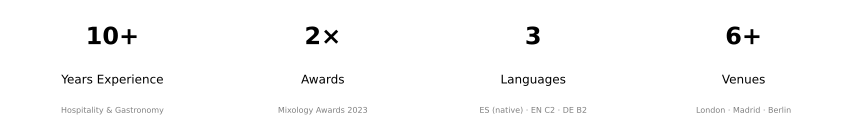

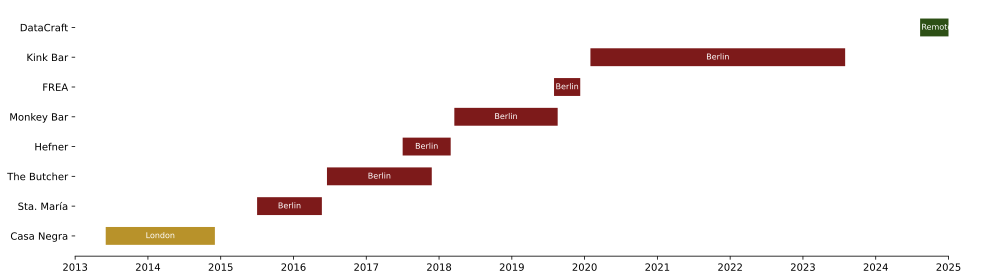

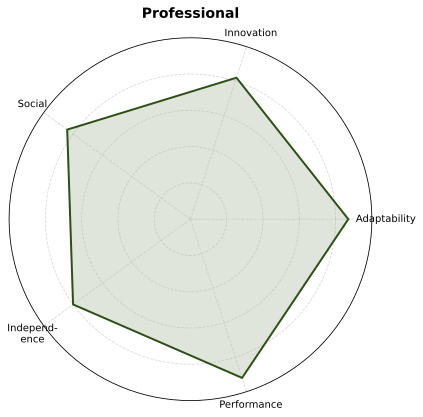

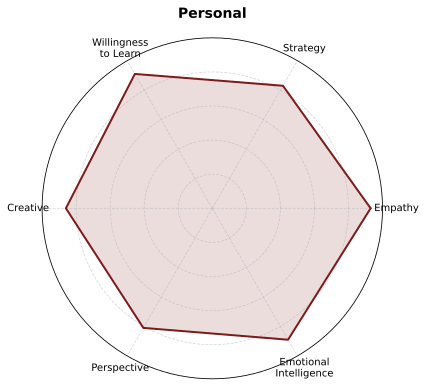

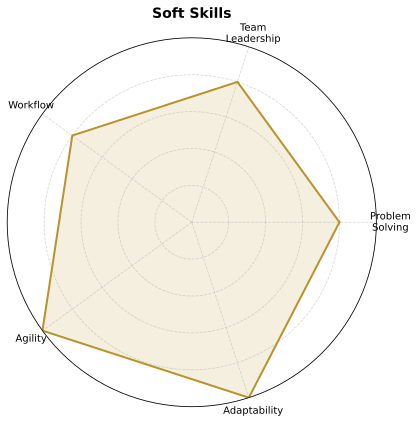

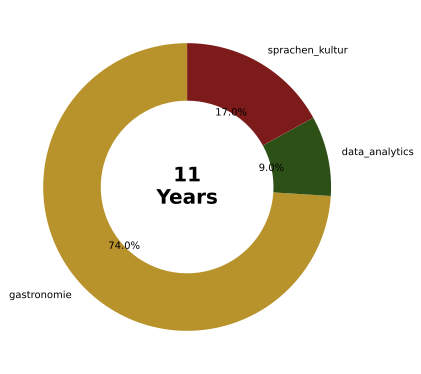

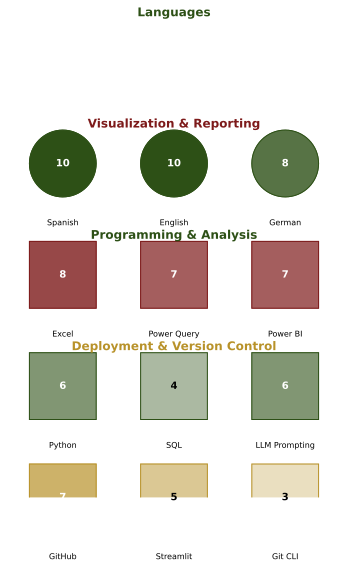

In [9]:
from IPython.display import SVG, display, HTML

# --- KPI Strip ---
display(HTML("<h3>KPI Strip</h3>"))
display(SVG(OUTPUT_DIR / "kpi.svg"))

# --- Timeline ---
display(HTML("<h3>Career Timeline</h3>"))
display(SVG(OUTPUT_DIR / "timeline.svg"))

# --- Radar Charts ---
display(HTML("<h3>Radar Charts</h3>"))
for r in data["radar"]["radars"]:
    fname = f"radar_{r['id']}.svg"
    display(HTML(f"<h4>{r['title_en']}</h4>"))
    display(SVG(OUTPUT_DIR / fname))

# --- Donut ---
display(HTML("<h3>Experience Distribution</h3>"))
display(SVG(OUTPUT_DIR / "donut.svg"))

# --- Pip Grid ---
display(HTML("<h3>Skills Grid</h3>"))
display(SVG(OUTPUT_DIR / "pip.svg"))